<a href="https://colab.research.google.com/github/MishaE-e/1/blob/main/%D0%95%D0%BB%D1%8C%D1%88%D0%B8%D0%BD_%D0%9C%D0%B8%D1%85%D0%B0%D0%B8%D0%BB_%D0%9D%D0%BE%D0%B2%D0%BE%D1%80%D0%BE%D1%81%D1%81%D0%B8%D0%B9%D1%81%D0%BA(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Конструирование признаков

Ельшин Михаил Алексеевич

группы ФМ/О РФЗ-1-2022 НБ

Лабораторная работа 2

В данном блокное решается задача подготовки данных для дальнейшего проведения анализа.

В качестве примера используется набор данныхо недвижимости в городах России. Данные можно посмотреть по ссылке https://www.kaggle.com/datasets/mrdaniilak/russia-real-estate-20182021. Из всего набора данных используются данные по Новороссийску.

Набор данных описывается следующими колонками

* date - дата публикации объявления;
* time - время публикации объявления;
* geo_lat - широта объекта недвижимости в градусах;
* geo_lon - долгота;
* region - код региона России (но с техническими правками).
* building_type - технология стройки: 0 - другая, 1 - панельный дом, 2 - монолитный каркас, 3 - кирпичный дом, 4 - блочный (газобетон, ПГП), 5 - деревянный;
* object_type - тип объекта: 1 - вторичный; 2 - первичная продажа от застройщика;
* level - этаж;
* levels - общее количество этажей в доме;
* rooms - количество жилых комнат: "-1" означает студию.
* area - общая площадь, кв.м.
* kitchen_area - площадь кухни, кв.м.
* price - цена, руб.

In [ ]:
import pandas as pd

Загружаем данные из файла

In [ ]:
df = pd.read_csv("all_v2.csv", parse_dates=['date'])
df

,price,date,time,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
0,6050000,2018-02-19,20:00:21,59.805808,30.376141,2661.0,1.0,8.0,10.0,3.0,82.6,10.8,1.0
1,8650000,2018-02-27,12:04:54,55.683807,37.297405,81.0,3.0,5.0,24.0,2.0,69.1,12.0,1.0
2,4000000,2018-02-28,15:44:00,56.295250,44.061637,2871.0,1.0,5.0,9.0,3.0,66.0,10.0,1.0
3,1850000,2018-03-01,11:24:52,44.996132,39.074783,2843.0,4.0,12.0,16.0,2.0,38.0,5.0,11.0
4,5450000,2018-03-01,17:42:43,55.918767,37.984642,81.0,3.0,13.0,14.0,2.0,60.0,10.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
84698,4500000,2018-09-18,10:15:53,55.419052,37.580115,81.0,3.0,5.0,5.0,3.0,97.5,10.0,1.0
84699,2850000,2018-09-18,10:16:16,55.743462,52.395916,2922.0,1.0,9.0,9.0,3.0,57.0,6.0,1.0
84700,2700000,2018-09-18,10:16:23,43.622654,39.720745,2843.0,2.0,3.0,12.0,1.0,27.0,7.0,11.0
84701,9299000,2018-09-18,10:16:33,55.634592,37.537053,3.0,1.0,6.0,9.0,3.0,58.0,6.0,1.0


Предоставление сведений о наборе данных

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84703 entries, 0 to 84702
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   price          84703 non-null  int64         
 1   date           84703 non-null  datetime64[ns]
 2   time           84703 non-null  object        
 3   geo_lat        84703 non-null  float64       
 4   geo_lon        84703 non-null  float64       
 5   region         84702 non-null  float64       
 6   building_type  84702 non-null  float64       
 7   level          84702 non-null  float64       
 8   levels         84702 non-null  float64       
 9   rooms          84702 non-null  float64       
 10  area           84702 non-null  float64       
 11  kitchen_area   84702 non-null  float64       
 12  object_type    84702 non-null  float64       
dtypes: datetime64[ns](1), float64(10), int64(1), object(1)
memory usage: 8.4+ MB


Вывод статистической информации о наборе данных.

In [ ]:
df.describe()

,price,date,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
count,8.470300e+04,84703,84703.000000,84703.000000,84702.000000,84702.000000,84702.000000,84702.000000,84702.000000,84702.000000,84702.000000,84702.000000
mean,4.531757e+06,2018-09-13 13:13:10.739407104,54.350664,50.361138,4047.497485,1.754988,6.273713,11.522290,1.800819,55.033988,11.056997,3.395221
min,-1.633967e+09,2018-02-19 00:00:00,41.459089,27.654370,3.000000,0.000000,1.000000,1.000000,-2.000000,5.000000,0.070000,1.000000
25%,1.800000e+06,2018-09-11 00:00:00,53.958315,37.505597,2661.000000,1.000000,3.000000,5.000000,1.000000,39.000000,7.000000,1.000000
50%,2.800000e+06,2018-09-14 00:00:00,55.434451,39.717210,2843.000000,2.000000,5.000000,10.000000,2.000000,49.000000,10.000000,1.000000
75%,4.900000e+06,2018-09-17 00:00:00,57.107905,60.827599,5520.000000,3.000000,9.000000,16.000000,2.000000,64.000000,13.000000,1.000000
max,1.680000e+09,2018-09-18 00:00:00,71.636251,129.848915,13919.000000,5.000000,34.000000,39.000000,9.000000,942.000000,187.170000,11.000000
std,1.986506e+07,NaN,5.080906,20.322085,3193.802271,1.152150,4.901794,6.413965,0.927118,26.423498,5.931553,4.267943


Фильтрация набора данных по году (2018).

In [ ]:
from datetime import datetime

In [ ]:
date2019 = datetime(2018, 1, 1)

In [ ]:
date2020 = datetime(2018, 12, 31)

In [ ]:
df= df[(df["date"]>=date2019) & (df["date"]<=date2020)]
df

,price,date,time,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
0,6050000,2018-02-19,20:00:21,59.805808,30.376141,2661.0,1.0,8.0,10.0,3.0,82.6,10.8,1.0
1,8650000,2018-02-27,12:04:54,55.683807,37.297405,81.0,3.0,5.0,24.0,2.0,69.1,12.0,1.0
2,4000000,2018-02-28,15:44:00,56.295250,44.061637,2871.0,1.0,5.0,9.0,3.0,66.0,10.0,1.0
3,1850000,2018-03-01,11:24:52,44.996132,39.074783,2843.0,4.0,12.0,16.0,2.0,38.0,5.0,11.0
4,5450000,2018-03-01,17:42:43,55.918767,37.984642,81.0,3.0,13.0,14.0,2.0,60.0,10.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
84698,4500000,2018-09-18,10:15:53,55.419052,37.580115,81.0,3.0,5.0,5.0,3.0,97.5,10.0,1.0
84699,2850000,2018-09-18,10:16:16,55.743462,52.395916,2922.0,1.0,9.0,9.0,3.0,57.0,6.0,1.0
84700,2700000,2018-09-18,10:16:23,43.622654,39.720745,2843.0,2.0,3.0,12.0,1.0,27.0,7.0,11.0
84701,9299000,2018-09-18,10:16:33,55.634592,37.537053,3.0,1.0,6.0,9.0,3.0,58.0,6.0,1.0


Фильтрация данных по координатам Новороссийска

In [ ]:
dfcoord = df[
    (df["geo_lat"] >= 44.6) &
    (df["geo_lat"] <= 44.8) &
    (df["geo_lon"] >= 37.6) &
    (df["geo_lon"] <= 37.9)
]
dfcoord

,price,date,time,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
242,2800000,2018-09-08,00:15:18,44.672702,37.787363,2843.0,2.0,5.0,16.0,2.0,60.0,11.8,1.0
248,2662000,2018-09-08,00:16:15,44.710944,37.777307,2843.0,2.0,4.0,12.0,1.0,48.4,15.1,1.0
251,6300000,2018-09-08,00:18:00,44.681239,37.786473,2843.0,2.0,5.0,6.0,3.0,136.0,10.0,1.0
293,2900000,2018-09-08,00:50:26,44.672702,37.787363,2843.0,2.0,4.0,16.0,2.0,60.3,10.7,11.0
304,4800000,2018-09-08,00:54:45,44.675917,37.789169,2843.0,2.0,13.0,14.0,3.0,107.0,13.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
84016,1550000,2018-09-18,08:59:47,44.728770,37.760475,2843.0,4.0,5.0,5.0,1.0,32.0,6.0,1.0
84056,1300000,2018-09-18,09:04:14,44.738685,37.713668,2843.0,4.0,3.0,3.0,1.0,32.5,8.9,11.0
84124,1760000,2018-09-18,09:10:18,44.738685,37.713668,2843.0,4.0,1.0,3.0,2.0,44.0,8.4,11.0
84356,4150000,2018-09-18,09:37:57,44.690357,37.791203,2843.0,2.0,13.0,20.0,2.0,60.0,10.0,11.0


Распределение объектов по координатам (карта).

In [ ]:
import seaborn as sns

<Axes: xlabel='geo_lon', ylabel='geo_lat'>

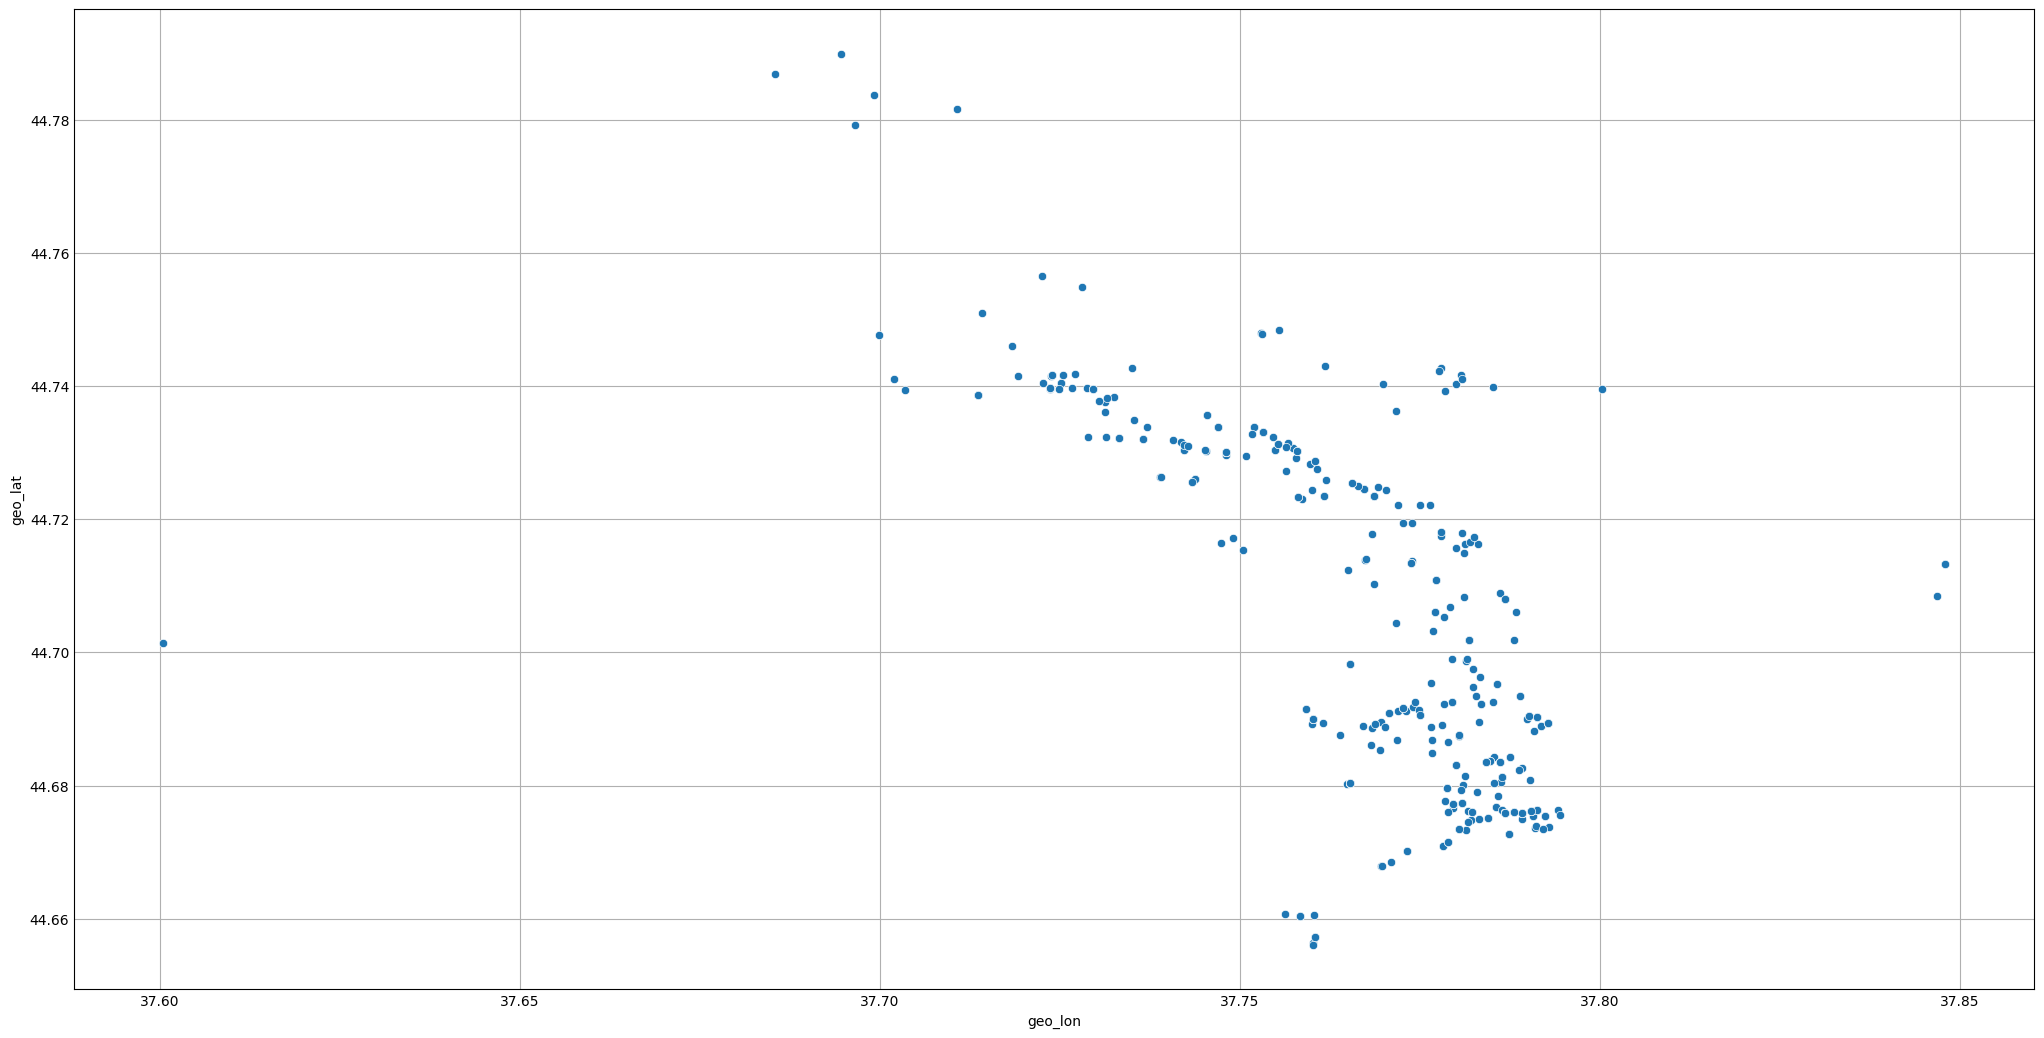

In [ ]:
fig, ax = plt.subplots(figsize=(20, 10))
sns.scatterplot(data=dfcoord, x="geo_lon", y="geo_lat")

координаты центар города.

In [ ]:
latc = 44.723771
lonc = 37.768808

Рассчёт расстояния вручную по теоремме Пифагора.

In [ ]:
from math import sqrt

In [ ]:
def distance(row):
    return sqrt((latc-row["geo_lat"])**2+(lonc-row["geo_lon"])**2)

In [ ]:
df_distance = dfcoord.copy()

In [ ]:
df_distance["distance"] = dfcoord.apply(lambda row: distance(row), axis=1)
df_distance

,price,date,time,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type,distance
242,2800000,2018-09-08,00:15:18,44.672702,37.787363,2843.0,2.0,5.0,16.0,2.0,60.0,11.8,1.0,0.054336
248,2662000,2018-09-08,00:16:15,44.710944,37.777307,2843.0,2.0,4.0,12.0,1.0,48.4,15.1,1.0,0.015387
251,6300000,2018-09-08,00:18:00,44.681239,37.786473,2843.0,2.0,5.0,6.0,3.0,136.0,10.0,1.0,0.046055
293,2900000,2018-09-08,00:50:26,44.672702,37.787363,2843.0,2.0,4.0,16.0,2.0,60.3,10.7,11.0,0.054336
304,4800000,2018-09-08,00:54:45,44.675917,37.789169,2843.0,2.0,13.0,14.0,3.0,107.0,13.0,1.0,0.052006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84016,1550000,2018-09-18,08:59:47,44.728770,37.760475,2843.0,4.0,5.0,5.0,1.0,32.0,6.0,1.0,0.009717
84056,1300000,2018-09-18,09:04:14,44.738685,37.713668,2843.0,4.0,3.0,3.0,1.0,32.5,8.9,11.0,0.057121
84124,1760000,2018-09-18,09:10:18,44.738685,37.713668,2843.0,4.0,1.0,3.0,2.0,44.0,8.4,11.0,0.057121
84356,4150000,2018-09-18,09:37:57,44.690357,37.791203,2843.0,2.0,13.0,20.0,2.0,60.0,10.0,11.0,0.040225


Используем библиотеку geopy для вычисления расстояния между двумя географическими точками

In [ ]:
from geopy import distance

In [ ]:
def distance2(row):
    return distance.distance((latc, lonc),(row["geo_lat"], row["geo_lon"])).km

In [ ]:
df_distance = dfcoord.copy()
df_distance["distance"] = dfcoord.apply(lambda row: distance2(row), axis=1)
df_distance

,price,date,time,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type,distance
242,2800000,2018-09-08,00:15:18,44.672702,37.787363,2843.0,2.0,5.0,16.0,2.0,60.0,11.8,1.0,5.862566
248,2662000,2018-09-08,00:16:15,44.710944,37.777307,2843.0,2.0,4.0,12.0,1.0,48.4,15.1,1.0,1.576479
251,6300000,2018-09-08,00:18:00,44.681239,37.786473,2843.0,2.0,5.0,6.0,3.0,136.0,10.0,1.0,4.929412
293,2900000,2018-09-08,00:50:26,44.672702,37.787363,2843.0,2.0,4.0,16.0,2.0,60.3,10.7,11.0,5.862566
304,4800000,2018-09-08,00:54:45,44.675917,37.789169,2843.0,2.0,13.0,14.0,3.0,107.0,13.0,1.0,5.557286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84016,1550000,2018-09-18,08:59:47,44.728770,37.760475,2843.0,4.0,5.0,5.0,1.0,32.0,6.0,1.0,0.862788
84056,1300000,2018-09-18,09:04:14,44.738685,37.713668,2843.0,4.0,3.0,3.0,1.0,32.5,8.9,11.0,4.671728
84124,1760000,2018-09-18,09:10:18,44.738685,37.713668,2843.0,4.0,1.0,3.0,2.0,44.0,8.4,11.0,4.671728
84356,4150000,2018-09-18,09:37:57,44.690357,37.791203,2843.0,2.0,13.0,20.0,2.0,60.0,10.0,11.0,4.115499


График позволяет визуализировать распределение точек на карте в зависимости от их расстояния до центра.

<Axes: xlabel='geo_lon', ylabel='geo_lat'>

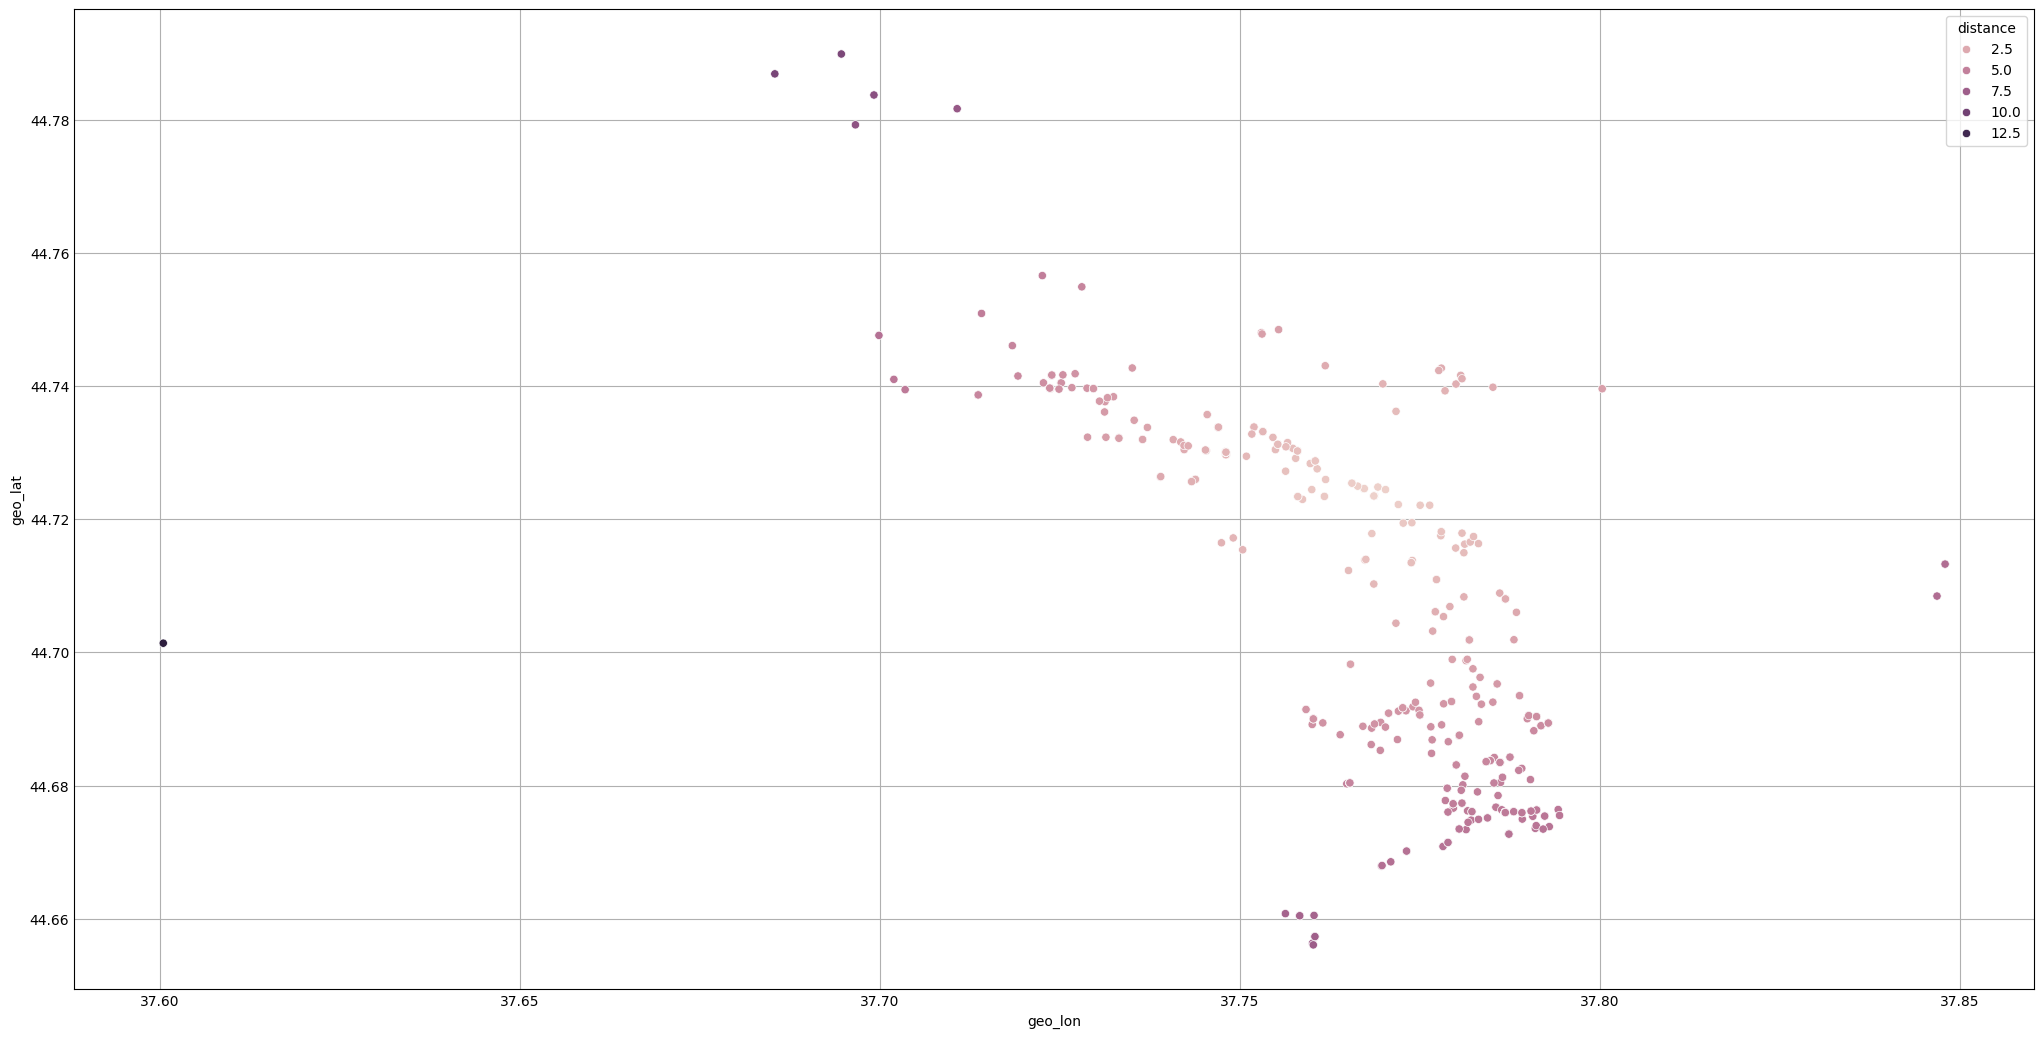

In [ ]:
sns.scatterplot(data=df_distance, x="geo_lon", y="geo_lat", hue="distance")

Удаляем отрицательные цены

In [ ]:
df_price = df_distance[(df_distance["price"]>=0) & (df_distance["price"]<=10000000)]
df_price

,price,date,time,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type,distance
242,2800000,2018-09-08,00:15:18,44.672702,37.787363,2843.0,2.0,5.0,16.0,2.0,60.0,11.8,1.0,5.862566
248,2662000,2018-09-08,00:16:15,44.710944,37.777307,2843.0,2.0,4.0,12.0,1.0,48.4,15.1,1.0,1.576479
251,6300000,2018-09-08,00:18:00,44.681239,37.786473,2843.0,2.0,5.0,6.0,3.0,136.0,10.0,1.0,4.929412
293,2900000,2018-09-08,00:50:26,44.672702,37.787363,2843.0,2.0,4.0,16.0,2.0,60.3,10.7,11.0,5.862566
304,4800000,2018-09-08,00:54:45,44.675917,37.789169,2843.0,2.0,13.0,14.0,3.0,107.0,13.0,1.0,5.557286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84016,1550000,2018-09-18,08:59:47,44.728770,37.760475,2843.0,4.0,5.0,5.0,1.0,32.0,6.0,1.0,0.862788
84056,1300000,2018-09-18,09:04:14,44.738685,37.713668,2843.0,4.0,3.0,3.0,1.0,32.5,8.9,11.0,4.671728
84124,1760000,2018-09-18,09:10:18,44.738685,37.713668,2843.0,4.0,1.0,3.0,2.0,44.0,8.4,11.0,4.671728
84356,4150000,2018-09-18,09:37:57,44.690357,37.791203,2843.0,2.0,13.0,20.0,2.0,60.0,10.0,11.0,4.115499


Переименование колонок для красивого построения графиков.

In [ ]:
df_price = df_price.rename(columns = {'geo_lon':'Долгота', 'geo_lat':'Широта', 'price':'Цена, руб'})
df_price

,"Цена, руб",date,time,Широта,Долгота,region,building_type,level,levels,rooms,area,kitchen_area,object_type,distance
242,2800000,2018-09-08,00:15:18,44.672702,37.787363,2843.0,2.0,5.0,16.0,2.0,60.0,11.8,1.0,5.862566
248,2662000,2018-09-08,00:16:15,44.710944,37.777307,2843.0,2.0,4.0,12.0,1.0,48.4,15.1,1.0,1.576479
251,6300000,2018-09-08,00:18:00,44.681239,37.786473,2843.0,2.0,5.0,6.0,3.0,136.0,10.0,1.0,4.929412
293,2900000,2018-09-08,00:50:26,44.672702,37.787363,2843.0,2.0,4.0,16.0,2.0,60.3,10.7,11.0,5.862566
304,4800000,2018-09-08,00:54:45,44.675917,37.789169,2843.0,2.0,13.0,14.0,3.0,107.0,13.0,1.0,5.557286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84016,1550000,2018-09-18,08:59:47,44.728770,37.760475,2843.0,4.0,5.0,5.0,1.0,32.0,6.0,1.0,0.862788
84056,1300000,2018-09-18,09:04:14,44.738685,37.713668,2843.0,4.0,3.0,3.0,1.0,32.5,8.9,11.0,4.671728
84124,1760000,2018-09-18,09:10:18,44.738685,37.713668,2843.0,4.0,1.0,3.0,2.0,44.0,8.4,11.0,4.671728
84356,4150000,2018-09-18,09:37:57,44.690357,37.791203,2843.0,2.0,13.0,20.0,2.0,60.0,10.0,11.0,4.115499


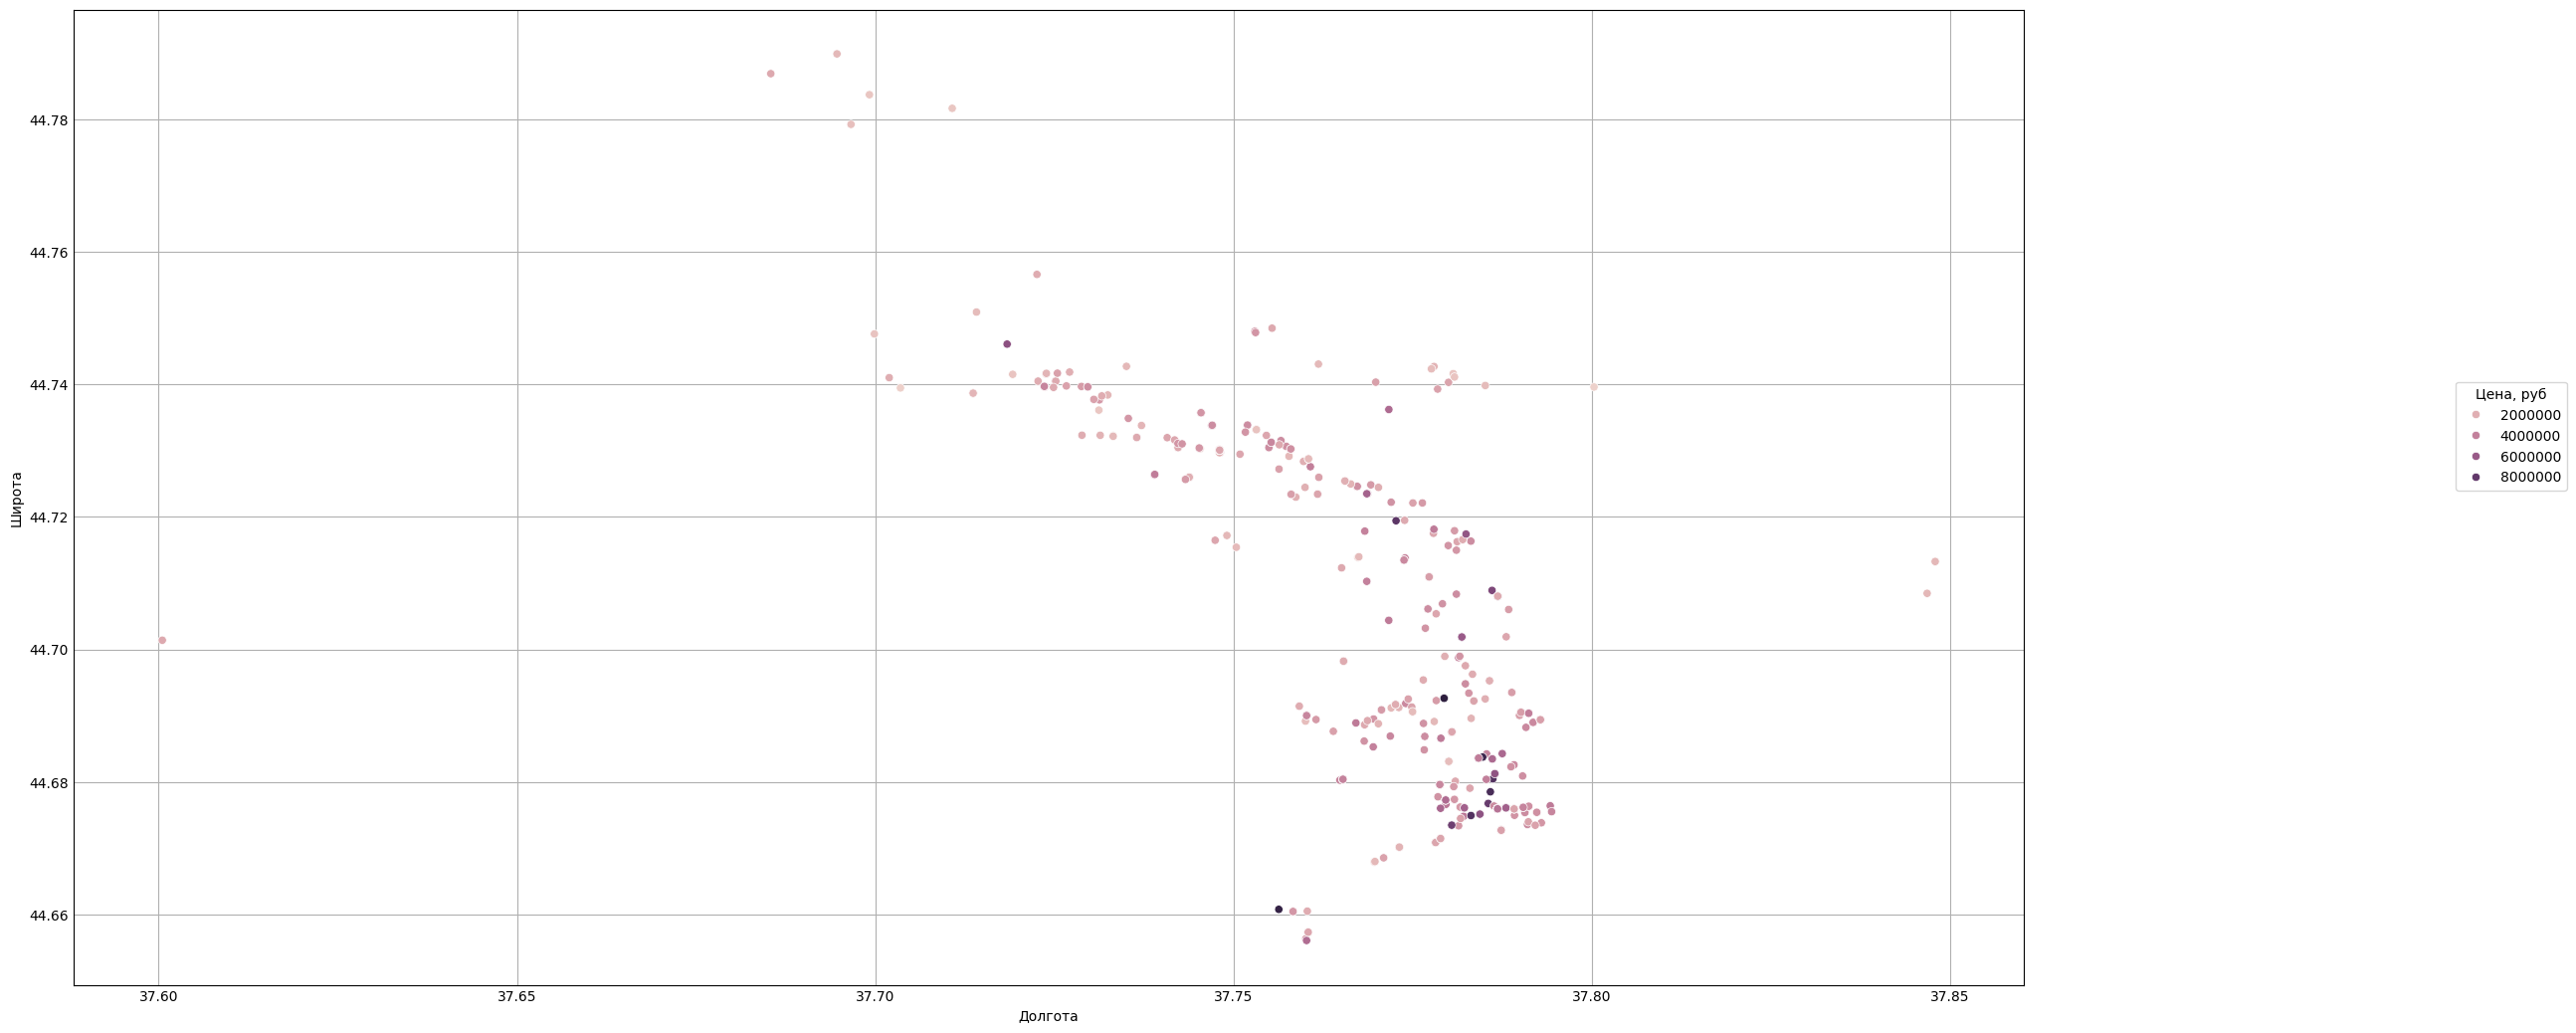

In [ ]:
ax = sns.scatterplot(data=df_price, x="Долгота", y="Широта", hue="Цена, руб")
sns.move_legend(ax, "lower center", bbox_to_anchor=(1.0, 0.5, 0.5, 0.5))

Отображение объектов на карте

In [ ]:
import folium

In [ ]:
map_nov = folium.Map(location=[latc, lonc], zoom_start=10)

for _, row in df_price.head(2000).iterrows():
    folium.Marker(location=[row['Широта'], row['Долгота']], popup=row['rooms']).add_to(map_nov)

map_nov

Создаем карту с цветными маркерами, представляющими объекты недвижимости, где цвет маркера зависит от ценового диапазона

In [ ]:
def color(row):
    if(row["Цена, руб"] < 1000000):
        return('darkgreen')
    elif(1000000 <= row["Цена, руб"] <2000000):
        return('green')
    elif(2000000 <= row["Цена, руб"] <5000000):
        return('orange')
    else:
        return('red')

In [ ]:
df_color = df_price.copy()
df_color["color"] = df_color.apply(lambda row: color(row), axis=1)

In [ ]:

map_nov = folium.Map(location=[latc, lonc], zoom_start=10)
for _, row in df_color.head(2000).iterrows():
    folium.CircleMarker(
        location=[row['Широта'], row['Долгота']],
        popup=row['rooms'],
        radius = 3,
        fill_color=row['color'],
        color="transparent",
        fill_opacity=1
    ).add_to(map_nov)
map_nov

In [ ]:
import matplotlib.pyplot as plt

Значение -1 ошибочно принято за проблему в данных, на самом деле оно обозначает студии, и их удалять нельзя.

In [ ]:
df_room_counts = df_color[(df_color["rooms"]>=1)]
df_room_counts_grouped = df_room_counts.groupby('rooms').count()
df_room_counts_grouped

,"Цена, руб",date,time,Широта,Долгота,region,building_type,level,levels,area,kitchen_area,object_type,distance,color
rooms,,,,,,,,,,,,,,
1.0,193,193,193,193,193,193,193,193,193,193,193,193,193,193
2.0,166,166,166,166,166,166,166,166,166,166,166,166,166,166
3.0,118,118,118,118,118,118,118,118,118,118,118,118,118,118
4.0,26,26,26,26,26,26,26,26,26,26,26,26,26,26
5.0,1,1,1,1,1,1,1,1,1,1,1,1,1,1


Пример построения столбчатой диаграммы распределения количества объектов по количеству команат с помощью библиотеки matplotlib.

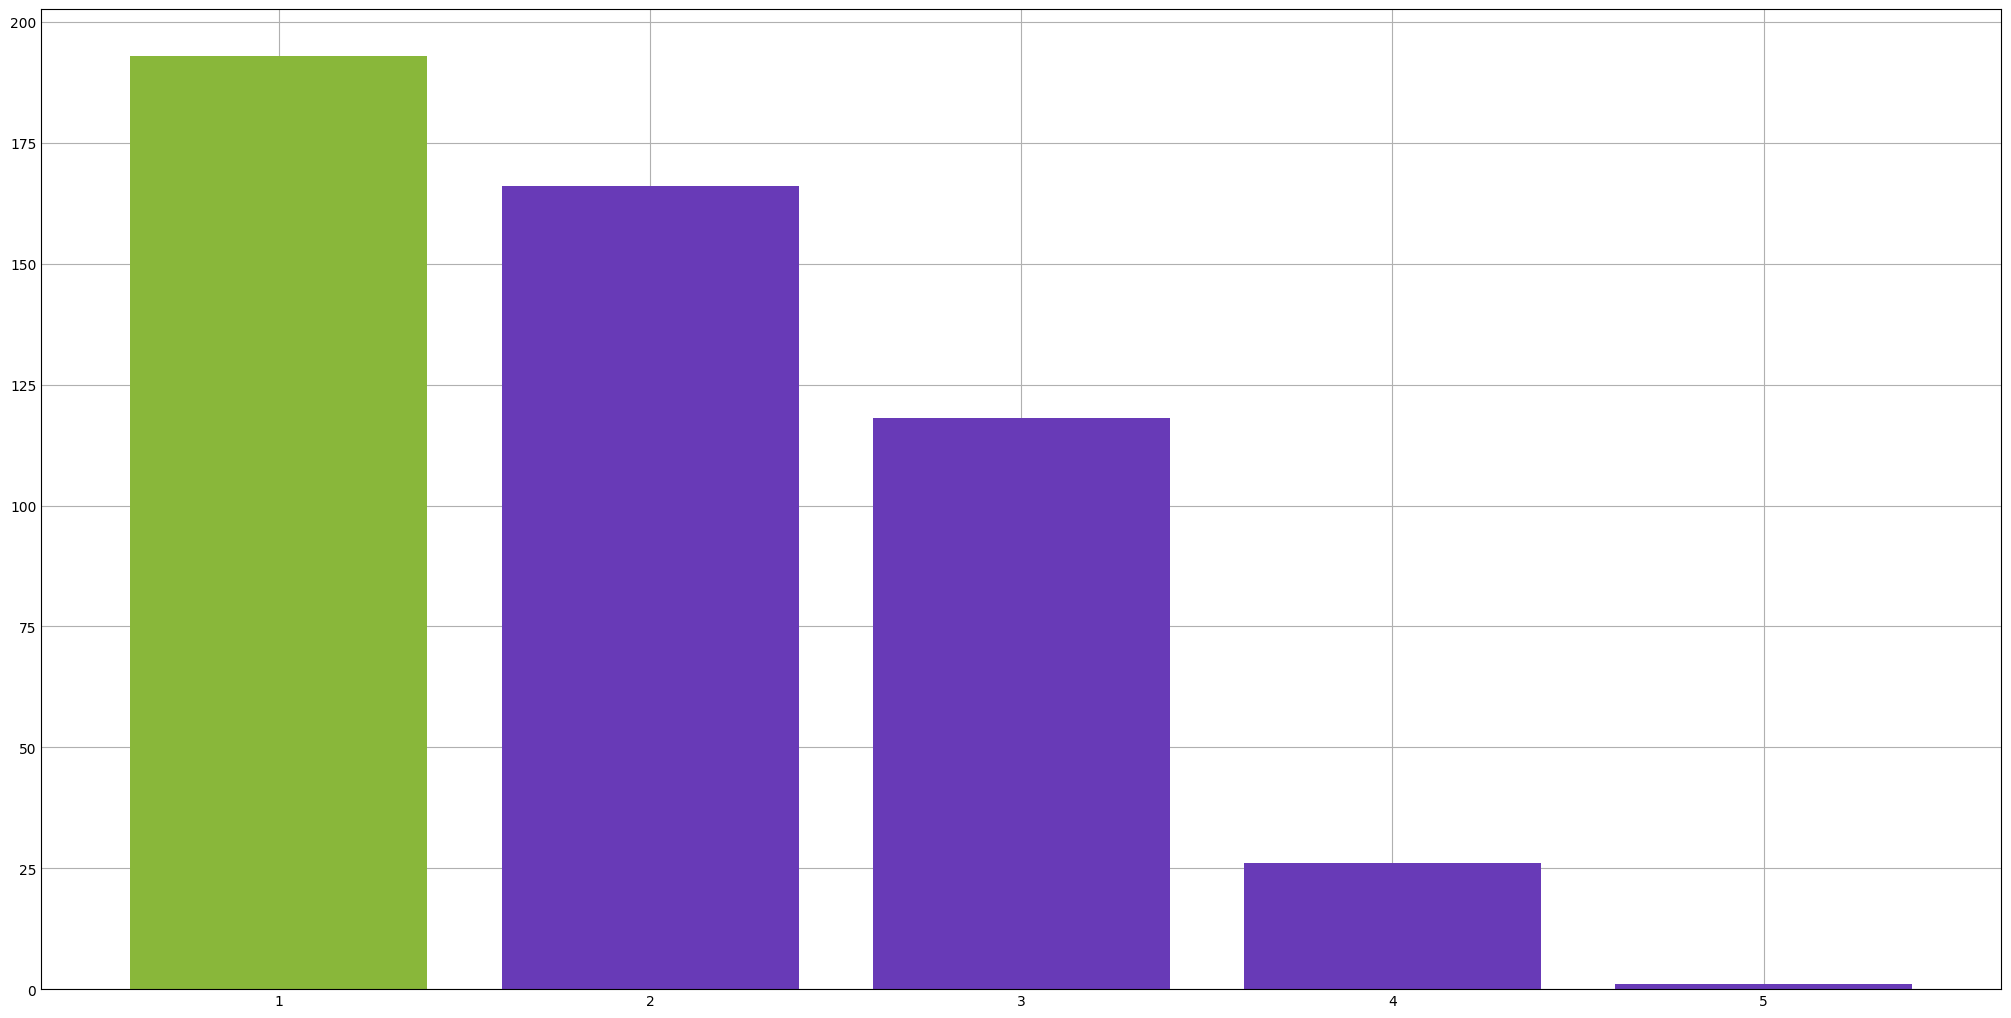

In [ ]:
plt.bar(
    df_room_counts_grouped.index, # количество комнат
    df_room_counts_grouped["date"],
    color=['#89b73a', '#683ab7', '#683ab7', '#683ab7', '#683ab7']
)
plt.xticks(df_room_counts_grouped.index)
plt.show()

Пример построения трехмерного графика.

In [ ]:
import numpy as np

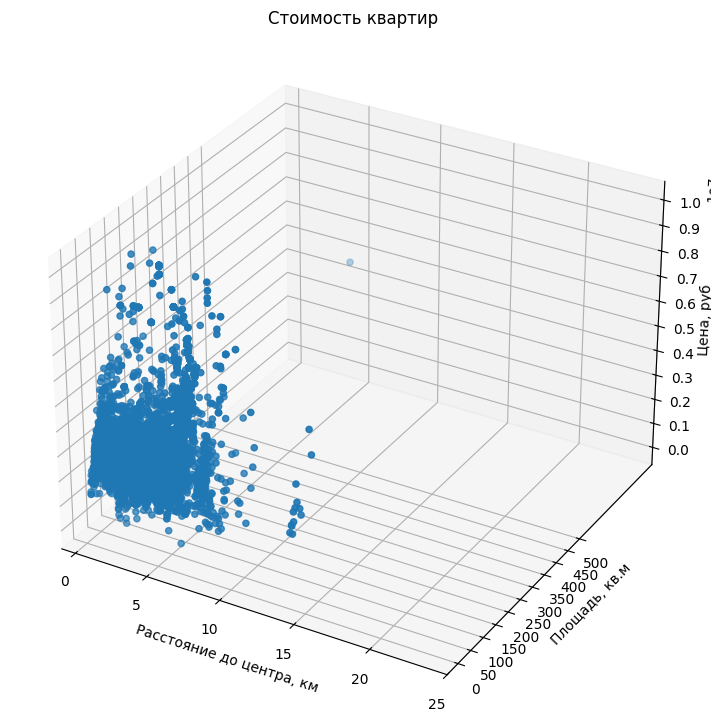

In [ ]:
plt.style.use('_mpl-gallery')
# Данные по осям
xs = df_room_counts["distance"]
ys = df_room_counts["area"]
zs = df_room_counts["Цена, руб"]
# Место под график (фигура и оси)
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(7, 7))
# Собственно сами данные в виде точечного графика.
ax.scatter(xs, ys, zs)
# Подписи осей
ax.set(
    xlabel='Расстояние до центра, км',
    ylabel='Площадь, кв.м',
    zlabel="Цена, руб",
    title="Стоимость квартир"
)
# Изменение положения подписо оси Z.
ax.zaxis.labelpad=0 # <- change the value here

# Отрезки по осям.
ax.set_xticks(np.linspace(0, 25, 6))
ax.set_yticks(np.linspace(0, 500, 11))
ax.set_zticks(np.linspace(0, 10000000, 11))
# Отображение графика.
plt.show()

Установка библиотеки panel

In [ ]:
%matplotlib inline

In [ ]:
import panel as pn

In [ ]:
%pip install jupyter_bokeh

In [ ]:
pn.extension()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
def my_square_func(x):
    return x*x

In [ ]:
pn.interact(my_square_func, x=10)

Column
    [0] Column
        [0] IntSlider(end=30, name='x', start=-10, value=10)
    [1] Row
        [0] Str(int, name='interactive00177')

In [ ]:
# Функция отрисовывает часть панели, которая реализуется с помощью matplotlib и seaborn.
def panel_matplotlib(
    roomsFilter
):
    # Фильтр данных в зависимости от выбранных пользователем значений параметров.
    df_temp = df_room_counts[
        (df_room_counts["rooms"]>=roomsFilter[0]) &
        (df_room_counts["rooms"]<=roomsFilter[1])
    ]

    fig, axd = plt.subplot_mosaic(
        [['left', 'right'],['bottom', 'bottom']],
        constrained_layout=True,
        figsize=(10, 10)
    )
    axd['left'].scatter(
        x=df_temp['area'],
        y=df_temp['Цена, руб'],
        color='#683ab7'
    )
    axd['left'].set(
        xlabel="Площадь, кв.м",
        ylabel="Цена, руб",
        title="Зависимость цены от площади квартиры"
    )
    # axd['left'].set_xlim([0,10])
    # axd['left'].set_ylim([0,30])
    axd['left'].legend()


    countsByRoomNumber = df_temp['rooms'].value_counts()

    # Второй график
    axd['right'].pie(
        countsByRoomNumber, #Распределение квартир по количеству комнат
        labels=countsByRoomNumber.index, # Названия секторов
        # colors=palette_color, # Цвета секторов
        #explode=explode, # Выдвижение секторов от центра
        autopct='%.0f%%'
    )

    sns.boxplot(
        #x="rooms",
        y="Цена, руб",
        hue="rooms",
        # palette=["m", "g"],
        data=df_temp,
        ax = axd['bottom']
    )
    # График надо закрыть, инче при изменений параметра он будет дорисовываться ниже, а не заменять предыдущую версию.
    plt.close(fig)
    # Из функции возвращаем отрисованную фигуру.
    return fig

In [ ]:
import folium
from folium.plugins import MarkerCluster

In [ ]:
def panel_folium(roomsFilter):
    # Фильтр данных
    df_temp = df_room_counts[
        (df_room_counts["rooms"] >= roomsFilter[0]) &
        (df_room_counts["rooms"] <= roomsFilter[1])
    ]

    # Собственно отрисовка карты.
    map_nov = folium.Map(location=[latc, lonc], zoom_start=10)

    # Создание кластера маркеров
    marker_cluster = MarkerCluster().add_to(map_nov)

    for _, row in df_temp.head(2000).iterrows():
        # Используем иконки для отображения цен
        folium.Marker(
            location=[row['Широта'], row['Долгота']],
            popup=f"Комнат: {row['rooms']}<br>Цена: {row['Цена, руб']} руб",
            icon=folium.Icon(color=row['color'], icon='info-sign')
        ).add_to(marker_cluster)

    return map_nov

/tmp/ipython-input-2642305984.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axd['left'].legend()


Column
    [0] IntRangeSlider(end=10, name='Количество комнат', value=(0, 5), value_end=5)
    [1] Matplotlib(Figure)
    [2] Folium(Map, height=600)
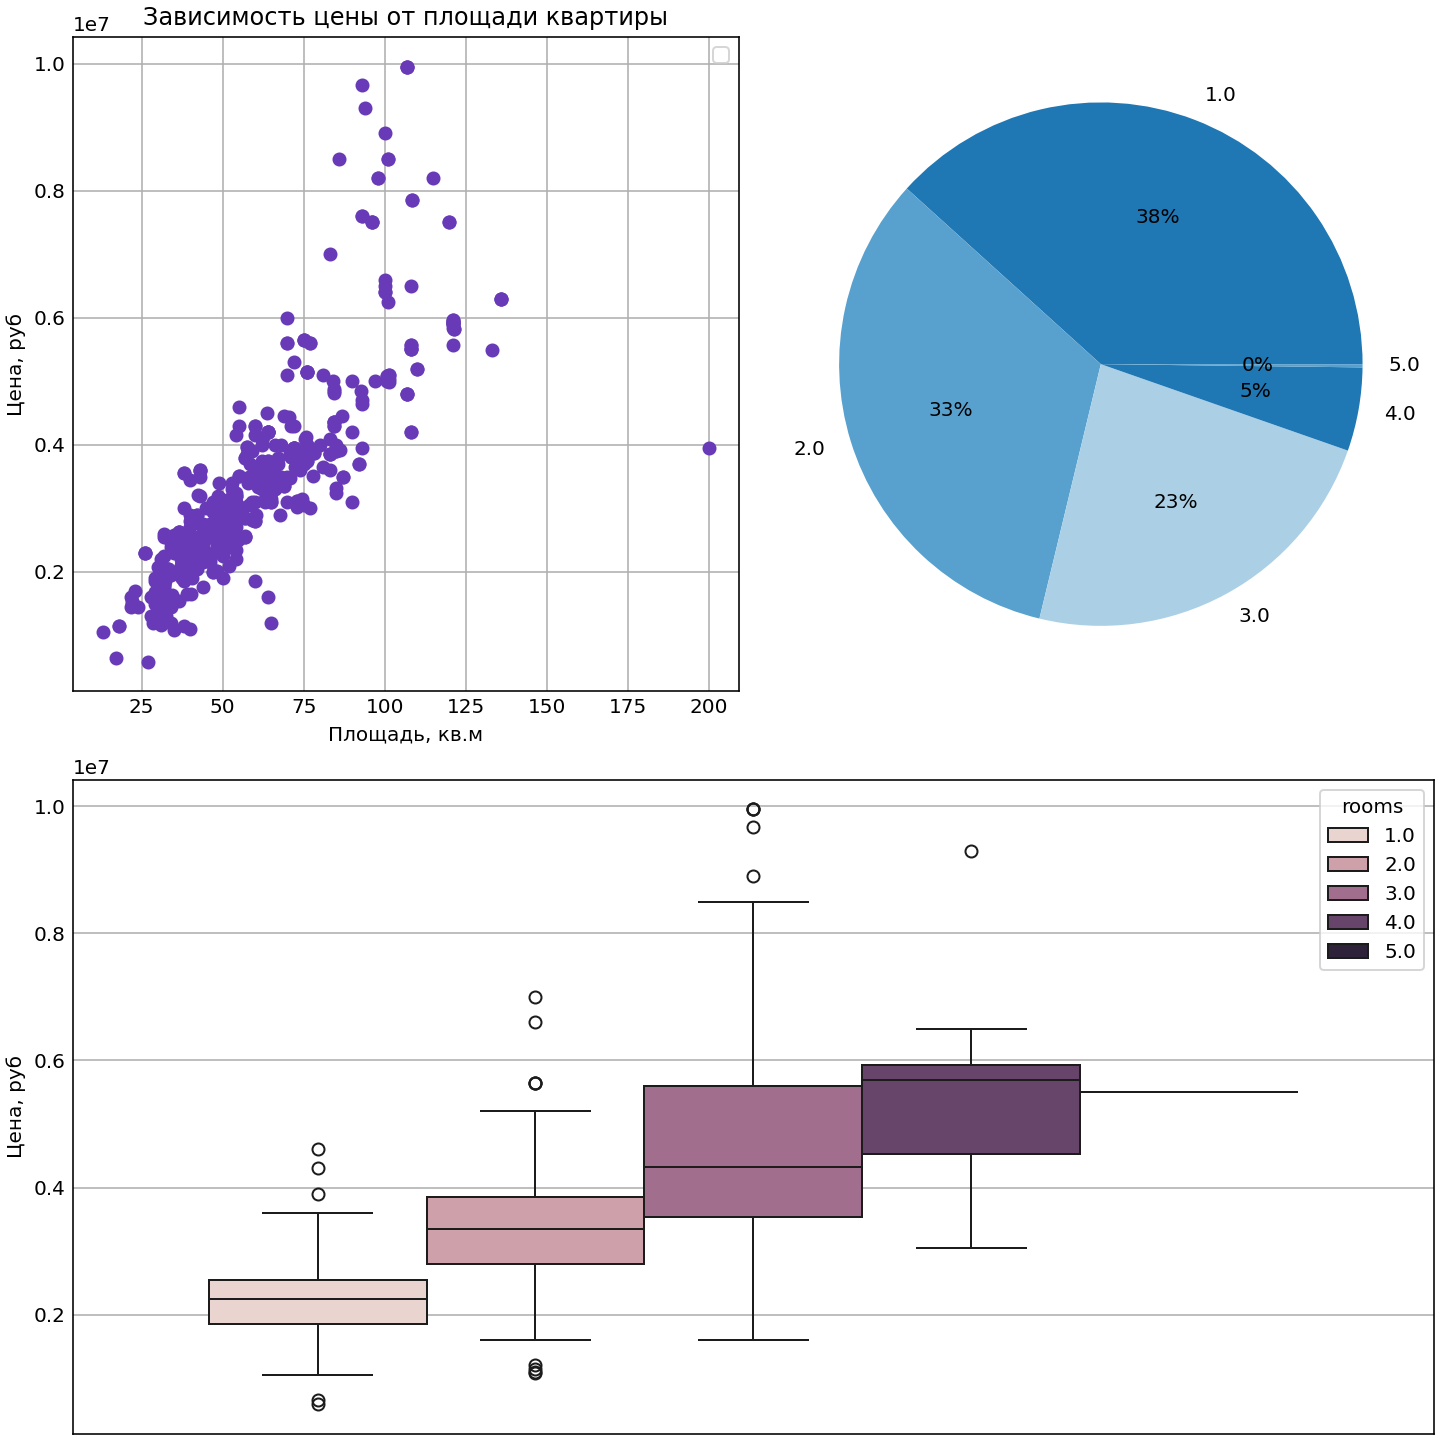

In [ ]:
# Полоска для нстройки фильтрации по количеству комнат.
sliderRooms = pn.widgets.IntRangeSlider(
    name='Количество комнат',
    start=0,
    end=10,
    value=(0, 5),
    step=1
).servable()
pane_mpl = pn.pane.Matplotlib(
    pn.bind(panel_matplotlib, sliderRooms)
)

pane_folium = pn.pane.plot.Folium(
    pn.bind(panel_folium, sliderRooms),
    height=600
)

pn.Column(
    sliderRooms,
    pane_mpl,
    pane_folium

).servable()

# **Заключение**
В ходе выполнения лабораторной работы произведены загрузка, фильтрация, обогащение, визуализация набора данных на примере данных из города Новороссийск за 2018 год. Создана комплексная система интерактивной аналитики рынка недвижимости.

Получены навыки:
1.   работы с табличными данными с помощью библиотеки pandas;
2.   графического представления данных с помощью библиотек matplotlib, seaborn, folium;
3.   построения аналитических панелей с помощью библиотеки panel.